# archiveWinston

### Modules

In [1]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
from obspy.clients.earthworm import Client as EWClient
from obspy.clients.seedlink import Client as SeedLinkClient
from obspy.core.trace import Trace
from obspy.core.stream import Stream
from obspy.signal.trigger import coincidence_trigger
from obspy import read
import numpy as np
from numpy import dtype
from scipy import stats
from scipy.fftpack import fft
import glob, os, itertools

In [2]:
import timeutils
import seismology.stream
import seismology.stream.datasource
from seismology.stream.datasource import createClient
from seismology.stream.nslcobject import str2nslc
from seismology.stream import removeWinstonGaps

In [3]:
def write2sds( st, basedir='./',
                    filestructure='BASEDIR/YEAR/NET/STA/CHAN.TYPE/NET.STA.LOC.CHAN.TYPE.YEAR.JDAY.EXTENSION',
                    format='mseed'):
    """
    WRITE2SDS Write to file in accordance w SDS file structure
    
    filestructure : str : Syntax for filestructure. Options are:
        Default: 'BASEDIR/YEAR/NET/STA/CHAN.TYPE/NET.STA.LOC.CHAN.TYPE.YEAR.JDAY.EXTENSION'
        Options:
        BASEDIR
        YEAR
        NET
        STA
        LOC
        CHAN
        TYPE
        YEAR
        JDAY
        DATE
        HOUR
        MINUTE
        SECOND
        #MISCROSEC
        EXTENSION
    """

    import os
    from pathlib import Path

    # Parse NSLC information from Stream (returned as string)
    network = st[0].stats.network
    station = st[0].stats.station
    location = st[0].stats.location
    channel = st[0].stats.channel

    # Assert datatype 'D'
    datatype = 'D'

    
    # Parse time information from Stream as zero-padded string
    year   = '{:04d}'.format(st[0].stats.starttime.year)       # Create zero-padded strings
    jday   = '{:03d}'.format(st[0].stats.starttime.julday)
    month  = '{:02d}'.format(st[0].stats.starttime.month)
    date   = '{:02d}'.format(st[0].stats.starttime.day)
    hour   = '{:02d}'.format(st[0].stats.starttime.hour)
    minute = '{:02d}'.format(st[0].stats.starttime.minute)
    second = '{:02d}'.format(st[0].stats.starttime.second)
    

    # Replace filestructure syntax with variables
    filestructure = filestructure.replace('BASEDIR', basedir)

    filestructure = filestructure.replace('NET', network)
    filestructure = filestructure.replace('STA', station)
    filestructure = filestructure.replace('LOC', location)
    filestructure = filestructure.replace('CHAN', channel)
    filestructure = filestructure.replace('TYPE', datatype)


    filestructure = filestructure.replace('YEAR', year)
    filestructure = filestructure.replace('MONTH', month)
    filestructure = filestructure.replace('DATE', date)
    filestructure = filestructure.replace('JDAY', jday)                   # Julian Day of Year

    filestructure = filestructure.replace('HOUR', hour)
    filestructure = filestructure.replace('MINUTE', minute)
    filestructure = filestructure.replace('SECOND', second)

    filestructure = filestructure.replace('EXTENSION', format)
    
    # Assert proper filestructure path and that create directories
    filestructure = os.path.normcase(os.path.normpath(filestructure)) # Normalize case of filepath; assert proper syntax
    filestructure = os.path.abspath(filestructure)         # Create absolte path if relative path given
    directories, filename = os.path.split(filestructure)   # Split into path filename
    Path(directories).mkdir(parents=True, exist_ok=True)   # Create all directories necessary
    
    # Write file!
    st.write(filestructure)
    
    # return filepath as variable
    return filestructure


In [4]:
#nslc_list = 'VG.PSAG.00.EHZ'
#type(nslc_list) is str

### Input Parameters

In [5]:
#server        = 'vdap.org'            # str : waveserver IP
#port          = 16024                 # int : waveserver port
ds             = 'wws:vdap.org:16024'  # str : file:/file/structure/ or wws:waveserverip:port

nslc_list     = ['VG.PSAG.00.EHZ']    # list or str : Stations to download (a single station may be entered as a str)
nslc_order    = 'nslc'                # str : Station code order : 'NSLC', 'SCNL', 'SCN'
nslc_out_list = ['VG.PSAG.01.EHZ']    # list or str : Replacement station code for output files
net, sta, loc, cha = 'VG', 'PSAG', '00', 'EHZ'

tstart        = '2017/09/18 11:02:06' # date format understood by ObsPy
tend          = '2017/09/18 11:03:46' # date format understand by ObsPy
tstart        = '2017/09/17 00:00:00' # date format understood by ObsPy
tend          = '2017/09/18 03:59:59.999' # date format understand by ObsPy

nsec          = 3600                  # int : Maximum amount of time to download at once (seconds)
nsecproc      = 86400                 # int : Maximum amount of time to process at once (seconds)

removeWWSgaps = True                  # bool : If True, removes -2**31 from all traces. Warning, False may cause errors when reading from WWS
verbose       = True

### Load, Process, Save

In [6]:
tstart = UTCDateTime(tstart)
tend = UTCDateTime(tend)
dt1 = tstart
dt2 = tend
client = createClient(ds)
stmp = client.get_waveforms(net, sta, loc, cha, dt1, dt2)
stmp = removeWinstonGaps(stmp)
stmp = stmp.merge(method=1, fill_value=0)
stmp[0].stats.location = '01'
filepath = write2sds(stmp, basedir='/Users/jjw2/Downloads/')

In [7]:
filepath

'/Users/jjw2/Downloads/2017/VG/PSAG/EHZ.D/VG.PSAG.01.EHZ.D.2017.260.mseed'

In [8]:
print(stmp[0].stats)
print(type(stmp[0].data[0]))

         network: VG
         station: PSAG
        location: 01
         channel: EHZ
       starttime: 2017-09-17T00:00:00.000000Z
         endtime: 2017-09-18T03:59:59.990000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 10080000
           calib: 1.0
      processing: ['ObsPy 1.2.2: trim(endtime=UTCDateTime(2017, 9, 18, 4, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2017, 9, 17, 0, 0))']
<class 'numpy.int32'>


In [9]:
from obspy.io.mseed.util import get_start_and_end_time
get_start_and_end_time(filepath)

(2017-09-17T00:00:00.000000Z, 2017-09-18T03:59:59.990000Z)

### Read header

In [10]:
stmp2 = read(filepath, headonly=True)
print(stmp2[0].stats)
print(4*60*100)

         network: VG
         station: PSAG
        location: 01
         channel: EHZ
       starttime: 2017-09-17T00:00:00.000000Z
         endtime: 2017-09-18T03:59:59.990000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 10080000
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 4832, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 4096, 'filesize': 19791872})
24000


In [11]:
for k, v in sorted(stmp2[0].stats.mseed.items()):
    print("'%s': %s" % (k, str(v))) 

'byteorder': >
'dataquality': D
'encoding': STEIM2
'filesize': 19791872
'number_of_records': 4832
'record_length': 4096


In [12]:
stmp3 = read(filepath)
print(type(stmp3[0].data))
print(type(stmp3[0].data[0]))

<class 'numpy.ndarray'>
<class 'numpy.int32'>


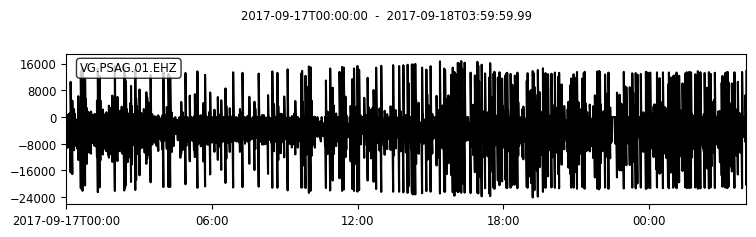

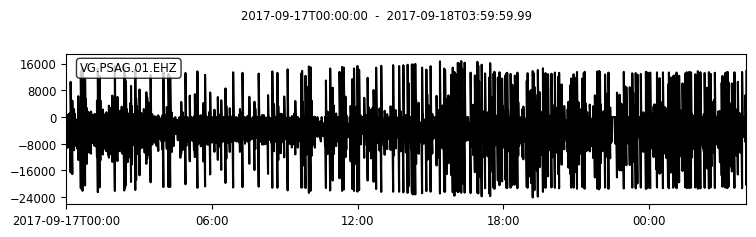

In [13]:
stmp.plot()

In [14]:
st

NameError: name 'st' is not defined

In [ ]:
st.plot()

In [ ]:
st[0].stats

In [ ]:
import matplotlib.pyplot as plt
plt.plot(st[0].data)

In [ ]:
j=2
stmp[j].data.dtype

In [ ]:
j
if stmp[j].data.dtype.name != 'int32':
    stmp[j].data=stmp[j].data.astype('int32')
if stmp[j].data.dtype!=dtype('int32'):
    stmp[j].data=stmp[j].data.astype('int32')
# deal with rare error when sub-traces have different sample rates
if stmp[j].stats.sampling_rate!=round(stmp[j].stats.sampling_rate):
    stmp[j].stats.sampling_rate=round(stmp[j].stats.sampling_rate)

In [ ]:
stmp[j].data.dtype

In [ ]:
st[0].data.dtype

In [ ]:
from obspy import read
st2 = read('/Users/jjw2/Downloads/2017/VG/PSAG/EHZ.D/VG.PSAG.01.EHZ.D.2017.261.mseed')

In [ ]:
st2

In [ ]:
st2[0].stats

In [ ]:
st2[0].data = st2[0].data.astype('int32')

In [ ]:
st2[0].stats

In [ ]:
type(st2[0].data[0])

In [ ]:
st2[0].stats.mseed['encoding'] = 'int32'

In [ ]:
st2[0].stats

In [ ]:
st2[0].data[0]

In [ ]:
st2[0].data = st2[0].data[:-1]
st2

In [ ]:
st2[0].stats